## =-=-=-=-= Global Social Media Impact on Teen Behaviour Analysis (2015–2060) =-=-=-=-=

# 1. Project Introduction
## Problem Statement

The increasing use of social media has significantly influenced teenagers' mental health, academic performance, sleep quality, and overall wellbeing. This project aims to examine these relationships, identify behavioural patterns, and uncover key risk factors through data-driven analysis.

## Dataset Overview

This project analyzes a comprehensive synthetic dataset containing over **464,000 records** of teenage social media behaviour across multiple countries from **2015 to 2060**. The dataset captures demographic characteristics, social media usage patterns, psychological wellbeing, physical health indicators, academic performance, family environment, digital safety, and future risk estimates.

The analysis aims to explore how different aspects of digital behaviour—such as screen time, social media usage, gaming activity, smartphone dependency, and online interactions—are associated with mental health, academic outcomes, sleep quality, and overall wellbeing among teenagers. The dataset also includes future risk indicators that support long-term behavioural trend analysis.

This project follows a complete Data Analytics workflow using **Python (Jupyter Notebook)** for data cleaning, exploratory data analysis (EDA), statistical analysis, **SQL** for business-oriented data querying, and **Power BI** for interactive dashboard development.

## Project Goal

The primary goal of this project is to uncover meaningful insights into the relationship between social media usage and teenage wellbeing through data-driven analysis.

The project focuses on:

* Analyzing global social media usage patterns among teenagers.
* Examining the impact of screen time on mental health, sleep quality, and academic performance.
* Identifying behavioural differences across countries, regions, genders, age groups, and income groups.
* Exploring relationships between digital addiction, family support, cyberbullying, and overall risk levels.
* Performing statistical and exploratory data analysis to discover significant trends and patterns.
* Generating business and policy-oriented insights using SQL queries.
* Developing interactive Power BI dashboards for effective visualization and decision-making.
* Demonstrating an end-to-end Data Analytics workflow suitable for portfolio, interview discussions, and real-world business analytics scenarios.



# 2. Import Libraries

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings("ignore")

# 3. Load Dataset

In [3]:
df = pd.read_csv('global_teen_social_media_behaviour_464k_2015_2060_synthetic.csv')

In [4]:
print("\nFirst 2 Rows:")
display(df.head(2))

print('\nTotal Number of Rows: ',df.shape[0])
print('Total Number of Columns: ',df.shape[1])
print('\nAll Columns Name:\n', list(df.columns))


First 2 Rows:


,record_id,country,continent,region,income_group,year,age,age_group,gender,urban_rural,...,forecast_addiction_risk_2030,forecast_addiction_risk_2040,forecast_mental_health_risk_2030,forecast_mental_health_risk_2040,synthetic_data_flag,screen_time_category,sleep_category,problematic_use_flag,high_mental_health_risk_flag,high_academic_risk_flag
0,1,United Kingdom,Europe,Western Europe,High,2048,19,16-19,Male,Urban,...,72.00,72.00,55.44,55.44,1,High,Healthy,1,0,0
1,2,Denmark,Europe,Northern Europe,High,2055,19,16-19,Male,Rural,...,77.04,77.04,55.73,55.73,1,Extreme,Low,1,0,0



Total Number of Rows:  464747
Total Number of Columns:  87

All Columns Name:
 ['record_id', 'country', 'continent', 'region', 'income_group', 'year', 'age', 'age_group', 'gender', 'urban_rural', 'internet_penetration_pct', 'smartphone_penetration_pct', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'educational_screen_hours', 'night_screen_time_hours', 'daily_notifications', 'age_first_smartphone', 'age_first_social_media', 'primary_platform', 'tiktok_hours', 'instagram_hours', 'youtube_hours', 'snapchat_hours', 'facebook_hours', 'x_twitter_hours', 'discord_hours', 'whatsapp_hours', 'social_media_addiction_score', 'smartphone_dependency_score', 'fear_of_missing_out_score', 'doomscrolling_score', 'anxiety_score', 'depression_score', 'stress_score', 'loneliness_score', 'self_esteem_score', 'body_image_concern_score', 'emotional_regulation_score', 'resilience_score', 'sleep_hours', 'sleep_quality_score', 'physical_activity_hours', 'outdoor_activity_hours', 'bmi_estimat

# 4. Dataset Information

In [5]:
print("\nColumn Informations:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())


Column Informations:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464747 entries, 0 to 464746
Data columns (total 87 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   record_id                           464747 non-null  int64  
 1   country                             464747 non-null  object 
 2   continent                           464747 non-null  object 
 3   region                              464747 non-null  object 
 4   income_group                        464747 non-null  object 
 5   year                                464747 non-null  int64  
 6   age                                 464747 non-null  int64  
 7   age_group                           464747 non-null  object 
 8   gender                              464747 non-null  object 
 9   urban_rural                         464747 non-null  object 
 10  internet_penetration_pct            464747 non-null  float64
 11  smar

,record_id,year,age,internet_penetration_pct,smartphone_penetration_pct,daily_screen_time_hours,social_media_hours,gaming_hours,educational_screen_hours,night_screen_time_hours,...,estimated_obesity_risk_probability,estimated_self_harm_risk_proxy,forecast_addiction_risk_2030,forecast_addiction_risk_2040,forecast_mental_health_risk_2030,forecast_mental_health_risk_2040,synthetic_data_flag,problematic_use_flag,high_mental_health_risk_flag,high_academic_risk_flag
count,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,...,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.000000,464747.0,464747.000000,464747.000000,464747.0
mean,232374.000000,2037.522809,14.495209,89.405689,87.254300,5.742739,3.072543,0.948397,0.918178,1.005075,...,0.377399,0.222187,56.885536,59.071796,42.748300,44.256560,1.0,0.146150,0.000389,0.0
std,134161.047115,13.266211,2.870777,10.884148,12.735092,1.740478,1.130349,0.491557,0.444069,0.449443,...,0.158337,0.066953,12.954815,12.345052,7.684761,7.395033,0.0,0.353257,0.019731,0.0
min,1.000000,2015.000000,10.000000,30.950000,19.580000,0.200000,0.100000,0.010000,0.010000,0.000000,...,0.000000,0.000000,7.210000,8.950000,11.190000,13.640000,1.0,0.000000,0.000000,0.0
25%,116187.500000,2026.000000,12.000000,82.290000,78.880000,4.510000,2.250000,0.550000,0.570000,0.690000,...,0.266200,0.176100,47.880000,50.520000,37.460000,39.190000,1.0,0.000000,0.000000,0.0
50%,232374.000000,2038.000000,14.000000,93.180000,91.020000,5.740000,2.970000,0.870000,0.850000,1.000000,...,0.376500,0.220300,56.260000,58.540000,42.500000,44.080000,1.0,0.000000,0.000000,0.0
75%,348560.500000,2049.000000,17.000000,99.000000,99.000000,6.980000,3.800000,1.270000,1.210000,1.310000,...,0.486900,0.266500,65.280000,67.100000,47.810000,49.160000,1.0,0.000000,0.000000,0.0
max,464747.000000,2060.000000,19.000000,99.000000,99.000000,12.600000,8.990000,3.360000,3.130000,3.340000,...,0.950000,0.544600,100.000000,100.000000,78.090000,78.090000,1.0,1.000000,1.000000,0.0


# 5. Data Quality Assessment

In [6]:
print('Missing Values:')
display(df.isnull().sum())

print('\nDuplicate records: ', df.duplicated().sum())

print('\nNumber of Unique Values Per Columns:')
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
}).sort_values(by='Unique Values',ascending=False)

display(unique_values)

display(Markdown("""
### Data Cleaning Summary:
The dataset was examined for missing values, duplicate records, and incorrect data types. No data quality issues were identified; therefore, no cleaning or preprocessing was required before analysis."""))

Missing Values:


record_id                       0
country                         0
continent                       0
region                          0
income_group                    0
                               ..
screen_time_category            0
sleep_category                  0
problematic_use_flag            0
high_mental_health_risk_flag    0
high_academic_risk_flag         0
Length: 87, dtype: int64


Duplicate records:  0

Number of Unique Values Per Columns:


,Column,Unique Values
0,record_id,464747
46,eye_strain_score,9656
55,parental_monitoring_score,9447
32,doomscrolling_score,9380
59,online_harassment_score,9346
...,...,...
57,cyberbullying_victim,2
85,high_mental_health_risk_flag,2
84,problematic_use_flag,2
81,synthetic_data_flag,1



### Data Cleaning Summary:
The dataset was examined for missing values, duplicate records, and incorrect data types. No data quality issues were identified; therefore, no cleaning or preprocessing was required before analysis.

# 6. Outlier Detection

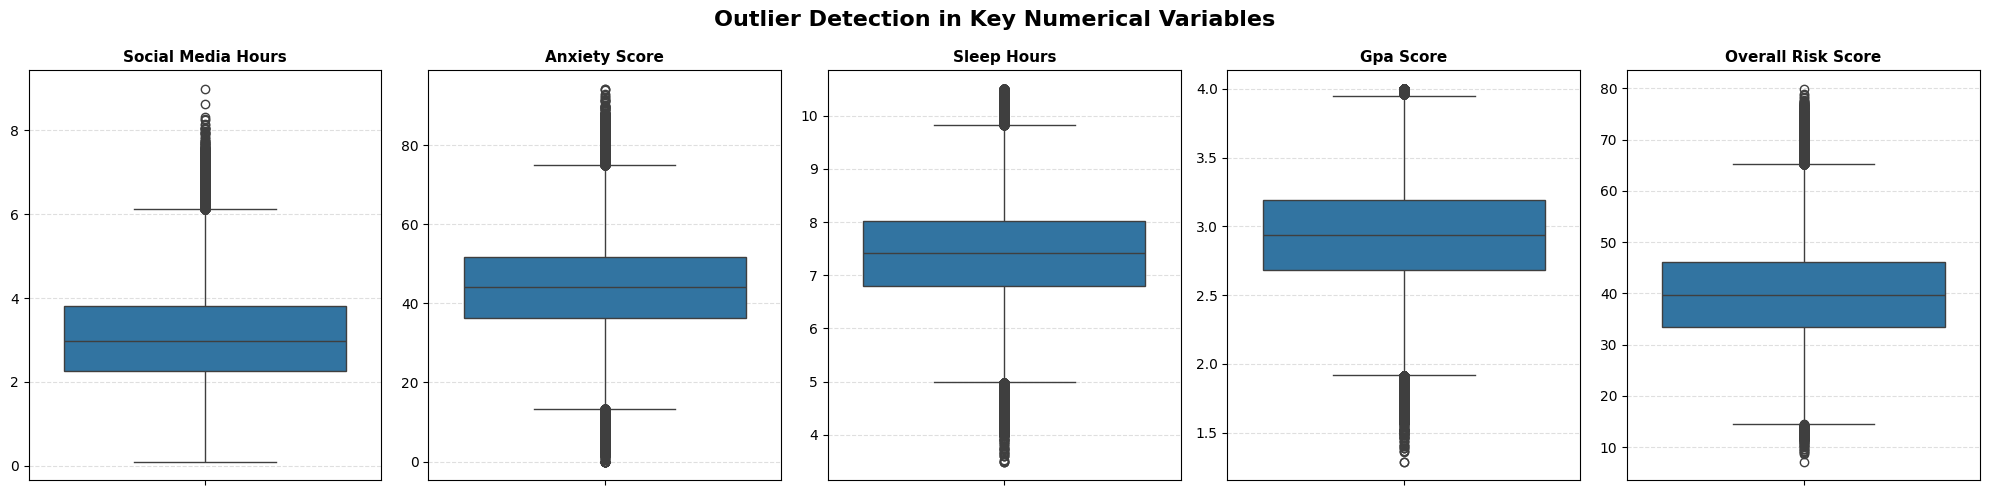

### Observation:
Box plots were used to examine potential outliers in key numerical variables. Outliers are present across all selected features, particularly in **Social Media Hours**, **Anxiety Score**, and **Overall Risk Score**. Since this is a synthetic dataset and these values likely represent realistic behavioural variations rather than data entry errors, the outliers were retained for subsequent analysis.

In [7]:
# Selected columns
columns = ['social_media_hours','anxiety_score','sleep_hours','gpa_score','overall_risk_score']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, col in zip(axes, columns):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_ylabel("")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Outlier Detection in Key Numerical Variables", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

display(Markdown("""### Observation:
Box plots were used to examine potential outliers in key numerical variables. Outliers are present across all selected features, particularly in **Social Media Hours**, **Anxiety Score**, and **Overall Risk Score**. Since this is a synthetic dataset and these values likely represent realistic behavioural variations rather than data entry errors, the outliers were retained for subsequent analysis."""))

# 7. Descriptive Statistics

In [8]:
# Selected columns
columns = ['social_media_hours','anxiety_score','sleep_hours','gpa_score','overall_risk_score'] 

summary = df[columns].agg(['mean','median','std']).T
summary.columns = ['Mean', 'Median', 'Standard Deviation']
display(summary)

display(Markdown("""### Observation:
The descriptive statistics provide an overview of the central tendency and variability of key numerical variables. Most features show a reasonable spread of values, indicating sufficient variation for further statistical analysis."""))

,Mean,Median,Standard Deviation
social_media_hours,3.072543,2.97,1.130349
anxiety_score,44.186571,44.09,11.433352
sleep_hours,7.400668,7.41,0.894546
gpa_score,2.934293,2.94,0.377474
overall_risk_score,40.033661,39.62,9.248967


### Observation:
The descriptive statistics provide an overview of the central tendency and variability of key numerical variables. Most features show a reasonable spread of values, indicating sufficient variation for further statistical analysis.

# 8. Correlation Analysis

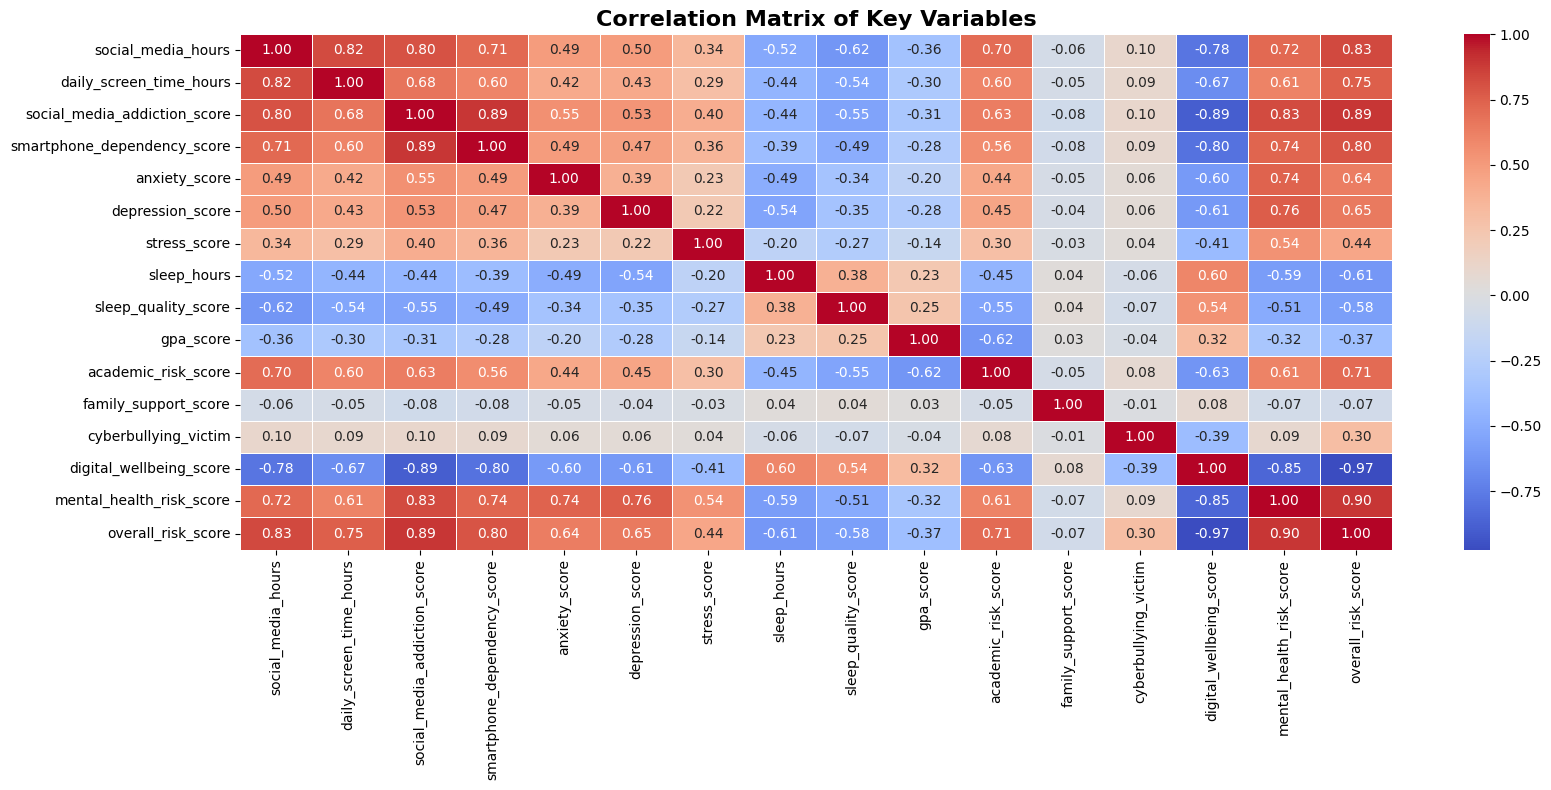

Top 10 Positive Correlations:



mental_health_risk_score      overall_risk_score              0.895107
social_media_addiction_score  overall_risk_score              0.893475
smartphone_dependency_score   social_media_addiction_score    0.892421
overall_risk_score            social_media_hours              0.830356
social_media_addiction_score  mental_health_risk_score        0.826245
daily_screen_time_hours       social_media_hours              0.823682
social_media_addiction_score  social_media_hours              0.800215
overall_risk_score            smartphone_dependency_score     0.797353
depression_score              mental_health_risk_score        0.762720
overall_risk_score            daily_screen_time_hours         0.753414
dtype: float64


Top 10 Negative Correlations:



digital_wellbeing_score       overall_risk_score            -0.974172
social_media_addiction_score  digital_wellbeing_score       -0.893831
mental_health_risk_score      digital_wellbeing_score       -0.853851
digital_wellbeing_score       smartphone_dependency_score   -0.797530
social_media_hours            digital_wellbeing_score       -0.781493
digital_wellbeing_score       daily_screen_time_hours       -0.670282
academic_risk_score           digital_wellbeing_score       -0.628370
gpa_score                     academic_risk_score           -0.624201
social_media_hours            sleep_quality_score           -0.620472
overall_risk_score            sleep_hours                   -0.611846
dtype: float64


### Key Correlation Insights:
1. **Mental Health Risk Score** and **Overall Risk Score** exhibit a very strong positive correlation (**r = 0.895**), indicating that higher mental health risks are closely associated with increased overall behavioural risk.
2. **Social Media Addiction Score** has a strong positive correlation with **Overall Risk Score** (**r = 0.893**), suggesting that greater social media addiction contributes significantly to higher overall risk.
3. **Smartphone Dependency Score** is strongly correlated with **Social Media Addiction Score** (**r = 0.892**), highlighting a close relationship between smartphone dependency and addictive social media behaviour.
4. **Daily Screen Time Hours** and **Social Media Hours** show a strong positive correlation (**r = 0.824**), indicating that teenagers with higher screen time also spend more time on social media.
5. **Digital Wellbeing Score** has a very strong negative correlation with **Overall Risk Score** (**r = -0.974**), suggesting that better digital wellbeing is strongly associated with lower behavioural risk.

In [9]:
# Select Important Features
corr_columns = [
    'social_media_hours','daily_screen_time_hours','social_media_addiction_score','smartphone_dependency_score','anxiety_score',
    'depression_score','stress_score','sleep_hours','sleep_quality_score','gpa_score','academic_risk_score','family_support_score',
    'cyberbullying_victim','digital_wellbeing_score','mental_health_risk_score','overall_risk_score'
]
# Correlation Matrix
corr_matrix = df[corr_columns].corr(method='pearson')

# Correlation Heatmap
plt.figure(figsize=(17,8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Matrix of Key Variables", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs.sort_values(ascending=False)
print('Top 10 Positive Correlations:\n')
display(corr_pairs.drop_duplicates().head(10))

print('\nTop 10 Negative Correlations:\n')
display(corr_pairs.sort_values().drop_duplicates().head(10))

display(Markdown("""
### Key Correlation Insights:
1. **Mental Health Risk Score** and **Overall Risk Score** exhibit a very strong positive correlation (**r = 0.895**), indicating that higher mental health risks are closely associated with increased overall behavioural risk.
2. **Social Media Addiction Score** has a strong positive correlation with **Overall Risk Score** (**r = 0.893**), suggesting that greater social media addiction contributes significantly to higher overall risk.
3. **Smartphone Dependency Score** is strongly correlated with **Social Media Addiction Score** (**r = 0.892**), highlighting a close relationship between smartphone dependency and addictive social media behaviour.
4. **Daily Screen Time Hours** and **Social Media Hours** show a strong positive correlation (**r = 0.824**), indicating that teenagers with higher screen time also spend more time on social media.
5. **Digital Wellbeing Score** has a very strong negative correlation with **Overall Risk Score** (**r = -0.974**), suggesting that better digital wellbeing is strongly associated with lower behavioural risk."""))

# 9. Statistical Analysis

## 9.1 Pearson Correlation Test

In [10]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['social_media_hours'], df['anxiety_score'])

print(f"Pearson Correlation Coefficient (r): {corr:.3f}")
print(f"P-value: {p_value:.5f}")

display(Markdown("""
### Interpretation
The Pearson correlation test indicates a statistically significant positive linear relationship between **Social Media Hours** and **Anxiety Score** (r = 0.493, p < 0.05). This suggests that teenagers who spend more time on social media tend to report higher anxiety levels."""))

Pearson Correlation Coefficient (r): 0.493
P-value: 0.00000



### Interpretation
The Pearson correlation test indicates a statistically significant positive linear relationship between **Social Media Hours** and **Anxiety Score** (r = 0.493, p < 0.05). This suggests that teenagers who spend more time on social media tend to report higher anxiety levels.

## 9.2 Spearman Correlation Test

In [11]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(df['social_media_addiction_score'], df['overall_risk_score'])

print(f"Spearman Correlation Coefficient (ρ): {corr:.3f}")
print(f"P-value: {p_value:.5f}")

display(Markdown("""
### Interpretation
The Spearman correlation test indicates a statistically significant positive monotonic relationship between **Social Media Addiction Score** and **Overall Risk Score** (ρ = 0.885, p < 0.05). This suggests that higher levels of social media addiction are consistently associated with increased overall behavioural risk."""))

Spearman Correlation Coefficient (ρ): 0.885
P-value: 0.00000



### Interpretation
The Spearman correlation test indicates a statistically significant positive monotonic relationship between **Social Media Addiction Score** and **Overall Risk Score** (ρ = 0.885, p < 0.05). This suggests that higher levels of social media addiction are consistently associated with increased overall behavioural risk.

## 9.3 Independent t-test

In [12]:
from scipy.stats import ttest_ind

# Separate groups
male = df[df['gender'] == 'Male']['anxiety_score']
female = df[df['gender'] == 'Female']['anxiety_score']

# Independent t-test
t_stat, p_value = ttest_ind(male, female)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")

display(Markdown("""
### Interpretation
The independent t-test was conducted to compare the mean anxiety scores between male and female teenagers.The test produced a **t-statistic of -0.832** and a **p-value of 0.40549**. Since the p-value is greater than the significance level of **0.05**, the null hypothesis cannot be rejected.This indicates that there is **no statistically significant difference** in the mean anxiety scores between male and female teenagers in this dataset."""))

T-statistic: -0.832
P-value: 0.40549



### Interpretation
The independent t-test was conducted to compare the mean anxiety scores between male and female teenagers.The test produced a **t-statistic of -0.832** and a **p-value of 0.40549**. Since the p-value is greater than the significance level of **0.05**, the null hypothesis cannot be rejected.This indicates that there is **no statistically significant difference** in the mean anxiety scores between male and female teenagers in this dataset.

## 9.4 One-way ANOVA

In [13]:
from scipy.stats import f_oneway

# Create groups dynamically
groups = [group["social_media_hours"].values for _, group in df.groupby("income_group")]

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

display(Markdown("""
### Interpretation
The One-Way ANOVA test was conducted to examine whether the average social media usage differs across different income groups.The test produced an **F-statistic of 1575.094** and a **p-value < 0.001**. Since the p-value is less than the significance level of **0.05**, the null hypothesis is rejected.This indicates that there is a **statistically significant difference** in the average social media usage among different income groups. In other words, income group appears to have a significant influence on teenagers' social media usage in this dataset."""))

F-statistic: 1575.094
P-value: 0.00000



### Interpretation
The One-Way ANOVA test was conducted to examine whether the average social media usage differs across different income groups.The test produced an **F-statistic of 1575.094** and a **p-value < 0.001**. Since the p-value is less than the significance level of **0.05**, the null hypothesis is rejected.This indicates that there is a **statistically significant difference** in the average social media usage among different income groups. In other words, income group appears to have a significant influence on teenagers' social media usage in this dataset.

## 9.5 Chi-Square Test

In [14]:
from scipy.stats import chi2_contingency

# Contingency Table
contingency_table = pd.crosstab(df['gender'], df['problematic_use_flag'])

display(contingency_table)

# Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.5f}")

display(Markdown("""
### Interpretation
The Chi-Square test was conducted to examine the association between **Gender** and **Problematic Social Media Use**.The test produced a **Chi-Square statistic of 2.538**, **2 degrees of freedom**, and a **p-value of 0.28114**. Since the p-value is greater than the significance level of **0.05**, the null hypothesis cannot be rejected.This indicates that there is **no statistically significant association** between gender and problematic social media use in this dataset. Based on the available data, problematic social media use appears to be independent of gender."""))

problematic_use_flag,0,1
gender,,
Female,194367,33101
Male,194380,33391
Non-binary/Other,8077,1431


Chi-Square Statistic: 2.538
Degrees of Freedom: 2
P-value: 0.28114



### Interpretation
The Chi-Square test was conducted to examine the association between **Gender** and **Problematic Social Media Use**.The test produced a **Chi-Square statistic of 2.538**, **2 degrees of freedom**, and a **p-value of 0.28114**. Since the p-value is greater than the significance level of **0.05**, the null hypothesis cannot be rejected.This indicates that there is **no statistically significant association** between gender and problematic social media use in this dataset. Based on the available data, problematic social media use appears to be independent of gender.

## 9.6 Statistical Interpretation

The statistical analysis provides valuable insights into the relationship between social media usage and teenage behavioural outcomes.

- Pearson and Spearman correlation tests revealed significant positive relationships between social media usage, addiction, and behavioural risk scores, indicating that increased digital engagement is associated with higher behavioural risk.

- The One-Way ANOVA test showed that average social media usage differs significantly across income groups, suggesting that socioeconomic background may influence teenagers' online behaviour.

- The Independent t-test found no statistically significant difference in anxiety scores between male and female teenagers, indicating that gender alone does not appear to influence anxiety levels in this dataset.

- The Chi-Square test also found no statistically significant association between gender and problematic social media use, suggesting that problematic usage patterns are not dependent on gender.

Overall, the statistical findings indicate that **behavioural factors such as social media addiction, screen time, and income group have a stronger relationship with teenage wellbeing than gender-related differences**.

# Conclusion

This project explored the impact of social media usage on teenage behaviour using a comprehensive synthetic dataset. Through data quality assessment, descriptive statistics, correlation analysis, and statistical hypothesis testing, several meaningful behavioural patterns were identified.

The findings indicate that higher social media usage, smartphone dependency, and addiction are strongly associated with increased behavioural and mental health risks, while better digital wellbeing is linked to lower overall risk. Statistical analysis also revealed significant differences in social media usage across income groups, whereas gender showed no significant influence on anxiety levels or problematic social media use.

Overall, this project demonstrates how Python, SQL, and Power BI can be combined to perform an end-to-end data analytics workflow, transforming raw data into actionable insights that support evidence-based decision-making.

In [17]:
sql_columns = [
    # Location
    'country','continent','region','income_group',
    # Demographics
    'age_group','gender','urban_rural',
    # Social Media
    'primary_platform','daily_screen_time_hours','social_media_hours','screen_time_category','social_media_addiction_score',
    'smartphone_dependency_score',
    # Mental Health
    'anxiety_score','depression_score','stress_score','mental_health_risk_score',
    # Physical Health
    'sleep_hours',
    # Academic
    'gpa_score','academic_risk_score','homework_completion_rate_pct',
    # Family
    'family_support_score',
    # Digital Safety
    'cyberbullying_victim',
    # Digital Wellbeing
    'digital_wellbeing_score',
    # Risk
    'overall_risk_score','risk_level','problematic_use_flag',
    # IDs (for ranking)
    'record_id'
]

sql_df = df[sql_columns]

## Connecting Python script to PostgreSQL

In [21]:
from sqlalchemy import create_engine

username = "postgres"
password = "Malay2200"   # the password you set in pgAdmin
host = "localhost"
port = "5432"
database = "social_media_impact_db"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

# Step 2: Load DataFrame into PostgreSQL
table_name = "social_media_impact"   # choose any table name
sql_df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'social_media_impact' in database 'social_media_impact_db'.
